In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
from scipy.stats import norm

from pathlib import Path
import re
import warnings

# USDC-USDT depeg: Residual diagnostics

- diagnostics on residuals from an ARIMA and GARCH(1,1) model
- evaluate stablecoin depeg against Gaussian/ Student-t innovations

In [6]:
!python depeg_bps_distribution.py

Diagnostics pipeline:   0%|                               | 0/8 [00:00<?, ?it/s][START] Load price series
[DONE ] Load price series in 0.09s
[START] Fit/load AutoARIMA
Loaded cached AutoARIMA residuals from cache/autoarima_fitted.parquet
[DONE ] Fit/load AutoARIMA in 0.01s
[START] Fit/load GARCH
Loaded cached GARCH residuals from cache/garch_1_1_fitted.parquet
[DONE ] Fit/load GARCH in 0.01s
[START] Prepare standardized diagnostic series
[DONE ] Prepare standardized diagnostic series in 0.00s
[START] Fit raw-scale distributions for AutoARIMA residuals
[DONE ] Fit raw-scale distributions for AutoARIMA residuals in 0.67s
[START] Fit raw-scale distributions for GARCH diagnostics
[DONE ] Fit raw-scale distributions for GARCH diagnostics in 0.59s
[START] Fit standardized Student-t for AutoARIMA QQ
[DONE ] Fit standardized Student-t for AutoARIMA QQ in 0.27s
[START] Fit standardized Student-t for GARCH QQ
[DONE ] Fit standardized Student-t for GARCH QQ in 0.30s
Diagnostics pipeline:  50%|███

# Characterising the quantile function for non distributional probabilitstic forecasting

## 1. Chebyshev basis quantile regression

- Regress quantile function using Chebyshev basis: 
    - Polynomial basis on [0,1]
- Quantile function should be monotone increasing 
    - regress $q = \frac{dQ}{d\tau}$  using Chebyshev + softplus
$$ q_t(\tau) = \mathrm{softplus}\left(\sum_k a_{k,t} T_k (2\tau -1) \right) $$

where $a_{k,t}$ given by NN.

Then $$ Q_t(\tau) = Q_t(0.5) + \int_{0.5}^{\tau} q_t(u)\,du $$

Montone increasing on $[0,1]$.

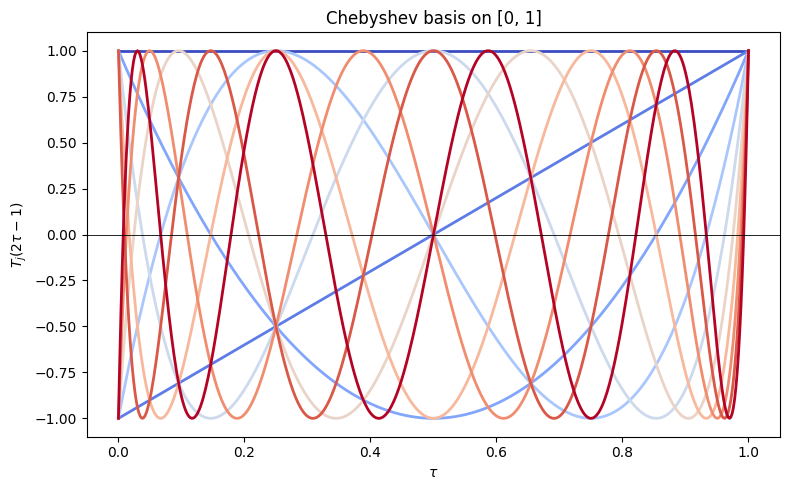

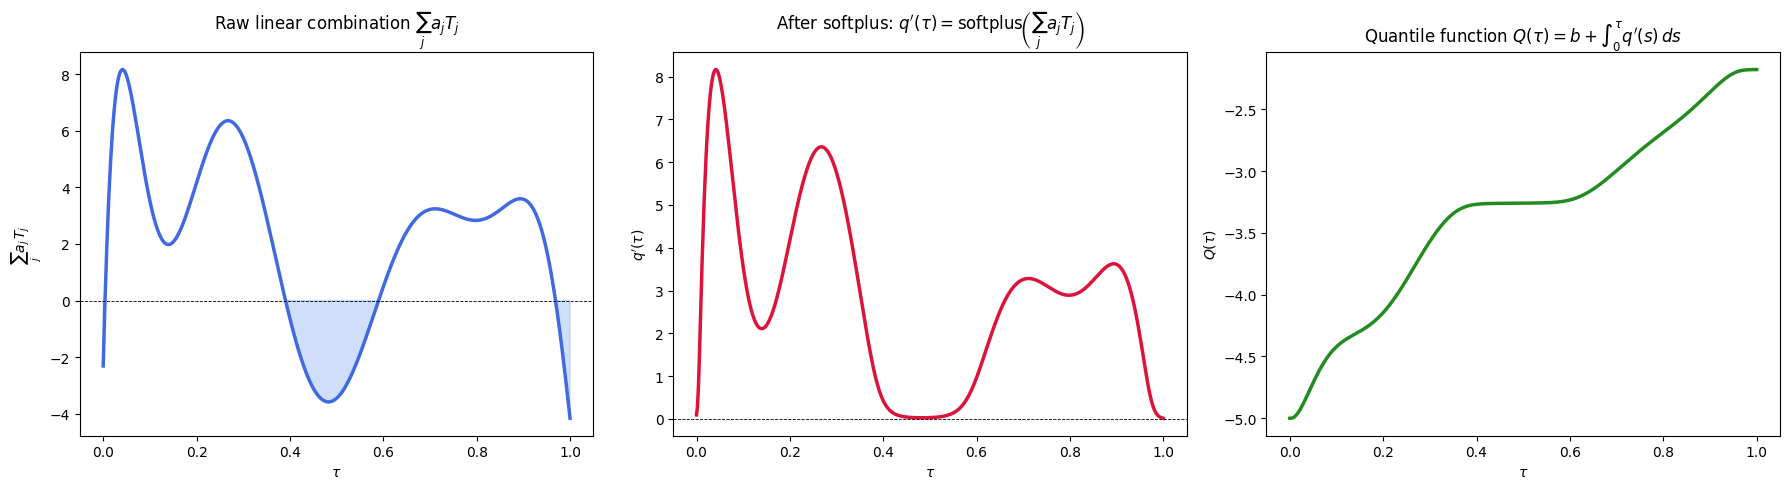

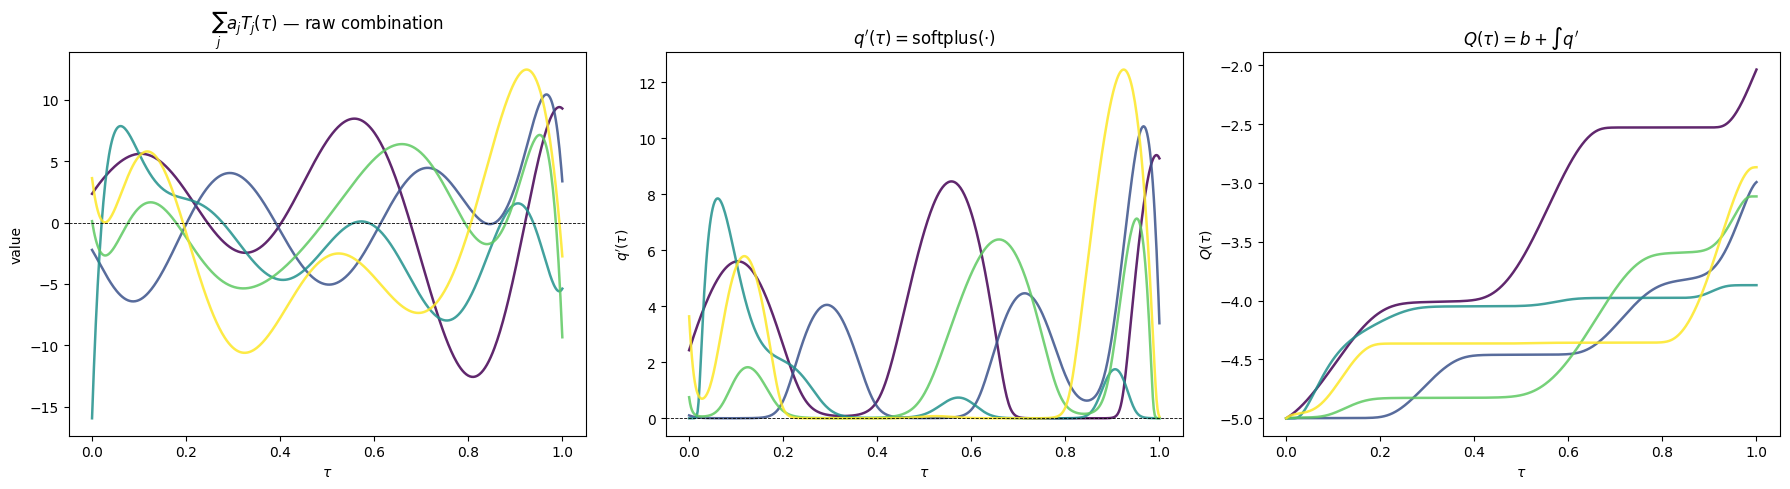

In [25]:
def softplus(z):
    # numerically stable log(1+exp(z))
    return np.logaddexp(0.0, z)

rng = np.random.default_rng(1233)
u = np.linspace(0, 1, 500)          # τ grid on [0,1]
x = 2 * u - 1                        # map to [-1,1] for Chebyshev

n_basis = 10  # number of Chebyshev basis functions to use

# ---- 1. build Chebyshev basis T_j on [0,1] ----
T = np.zeros((len(u), n_basis))
for j in range(n_basis):
    T[:, j] = np.cos(j * np.arccos(x))

# ---- 2. random coefficients (a NN would output these) ----
raw_a = rng.normal(size=n_basis) * 1.5
raw_a[0] = 2.0   # positive offset so the mean level is reasonable

# linear combination (can be negative)
lin_comb = T @ raw_a

# softplus → positive quantile density
q_density = softplus(lin_comb)

# ---- 3. integrate to get Q(τ) ----
b0 = -5.0  # location shift
Q_cheb = b0 + np.concatenate([[0], np.cumsum(0.5 * (q_density[1:] + q_density[:-1]) * np.diff(u))])

# ========================  PLOT 1 : Chebyshev basis  ========================
fig, axes = plt.subplots(1, 1, figsize=(8, 5))

for j in range(n_basis):
    c = matplotlib.cm.coolwarm(j / (n_basis - 1))
    axes.plot(u, T[:, j], color=c, lw=2, label=rf"$T_{{{j}}}$")

axes.set_xlabel(r"$\tau$")
axes.set_ylabel(r"$T_j(2\tau - 1)$")
axes.set_title("Chebyshev basis on [0, 1]")
axes.axhline(0, color="k", lw=0.6)

plt.tight_layout()
plt.savefig("figures/chebyshev_basis.png", dpi=300, transparent=True, bbox_inches="tight")
plt.show()

# ==================  PLOT 2 : softplus mechanism  ==========================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# raw linear combination (can be negative)
axes[0].plot(u, lin_comb, color="royalblue", lw=2.5)
axes[0].axhline(0, color="k", lw=0.6, ls="--")
axes[0].fill_between(u, lin_comb, 0, where=lin_comb < 0, color="cornflowerblue", alpha=0.3, label="negative region")
axes[0].set_xlabel(r"$\tau$")
axes[0].set_ylabel(r"$\sum_j a_j\, T_j$")
axes[0].set_title(r"Raw linear combination $\sum_j a_j T_j$")
# axes[0].legend(frameon=False)

# after softplus → strictly positive quantile density
axes[1].plot(u, q_density, color="crimson", lw=2.5)
# axes[1].fill_between(u, q_density, 0, color="crimson", alpha=0.15)
axes[1].axhline(0, color="k", lw=0.6, ls="--")
axes[1].set_xlabel(r"$\tau$")
axes[1].set_ylabel(r"$q'(\tau)$")
axes[1].set_title(r"After softplus: $q'(\tau) = \mathrm{softplus}\!\left(\sum_j a_j T_j\right)$")

# quantile function (integral)
axes[2].plot(u, Q_cheb, color="forestgreen", lw=2.5)
axes[2].set_xlabel(r"$\tau$")
axes[2].set_ylabel(r"$Q(\tau)$")
axes[2].set_title(r"Quantile function $Q(\tau) = b + \int_0^{\tau} q'(s)\,ds$")

plt.tight_layout()
plt.savefig("figures/chebyshev_softplus_pipeline.png", dpi=300, transparent=True, bbox_inches="tight")
plt.show()

# ======  PLOT 3 : different coefficient draws → different Q shapes  ========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
n_draws = 5
for k in range(n_draws):
    c = matplotlib.cm.viridis(k / (n_draws - 1))
    raw = rng.normal(size=n_basis) * 2.0
    lc = T @ raw
    qd = softplus(lc)
    Qk = b0 + np.concatenate([[0], np.cumsum(0.5 * (qd[1:] + qd[:-1]) * np.diff(u))])
    axes[0].plot(u, lc, color=c, lw=1.8, alpha=0.85)
    axes[1].plot(u, qd, color=c, lw=1.8, alpha=0.85)
    axes[2].plot(u, Qk, color=c, lw=1.8, alpha=0.85)

axes[0].axhline(0, color="k", lw=0.6, ls="--")
axes[0].set_title(r"$\sum_j a_j T_j(\tau)$ — raw combination")
axes[0].set_xlabel(r"$\tau$"); axes[0].set_ylabel("value")

axes[1].axhline(0, color="k", lw=0.6, ls="--")
axes[1].set_title(r"$q'(\tau) = \mathrm{softplus}(\cdot)$")
axes[1].set_xlabel(r"$\tau$"); axes[1].set_ylabel(r"$q'(\tau)$")

axes[2].set_title(r"$Q(\tau) = b + \int q'$")
axes[2].set_xlabel(r"$\tau$"); axes[2].set_ylabel(r"$Q(\tau)$")

plt.tight_layout()
plt.savefig("figures/chebyshev_multiple_draws.png", dpi=300, transparent=True, bbox_inches="tight")
plt.show()


## 2. I-spline basis for quantile function regression

- I splines are integrated M-splines: polynomial basis monotone increasing by construction
- $Q$ can be regressed directly as:
$$ Q_t(\tau) = b_t + \sum_k \mathrm{softplus}(a_{k,t}) I_k(\tau)$$

- I spline sequence determined by set of knots $t_1 \leq t_2 \leq ... \leq t_{n+1} \in ]0,1[$ 
    - knot density determines tail focus for quantile function

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BSpline
import matplotlib
import numpy as np

def make_open_knots_from_internal(internal, a=0.0, b=1.0, degree=3):
    """
    Open knot vector on [a,b] with user-specified *internal* knots (non-uniform allowed).

    Parameters
    ----------
    internal : array-like
        Strictly increasing knots inside (a,b). Can be empty.
    a, b : float
        Boundary of domain.
    degree : int
        Spline degree (cubic=3). Boundaries are repeated degree+1 times (open/clamped).

    Returns
    -------
    knots : np.ndarray
        Knot vector of length (len(internal) + 2*(degree+1)).
    """
    internal = np.asarray(internal, dtype=float)
    if internal.size > 0:
        if not np.all(np.diff(internal) > 0):
            raise ValueError("internal knots must be strictly increasing")
        if internal.min() <= a or internal.max() >= b:
            raise ValueError("internal knots must lie strictly inside (a,b)")

    k = int(degree)
    knots = np.r_[np.repeat(a, k + 1), internal, np.repeat(b, k + 1)]
    return knots


def make_open_nonuniform_knots(n_basis=9, degree=3, a=0.0, b=1.0, kind="beta", p=3.0):
    """
    Convenience generator for non-uniform internal knots (more dense near tails by default),
    then wraps them as open/clamped knots.

    kind:
      - "beta": internal knots from a Beta(p,p) quantile grid (tail-dense when p<1, center-dense when p>1)
      - "power_tails": explicit tail-dense mapping (p>1 gives more tail density)
      - "uniform": uniform internal knots (same as your original)
    """
    k = degree
    n_internal = n_basis - (k + 1)
    if n_internal < 0:
        raise ValueError("n_basis must be >= degree+1")

    if n_internal == 0:
        internal = np.array([])
        return make_open_knots_from_internal(internal, a=a, b=b, degree=degree)

    if kind == "uniform":
        internal = np.linspace(a, b, n_internal + 2)[1:-1]

    elif kind == "power_tails":
        # more knots near a and b, fewer near the middle
        t = np.linspace(0, 1, n_internal + 2)[1:-1]
        u = 0.5 + 0.5*np.sign(t - 0.5) * np.abs(2*t - 1)**p  # p>1 => tail-dense
        internal = a + (b - a) * u

    elif kind == "beta":
        # uses a symmetric beta grid; needs scipy if you want true beta quantiles.
        # Here is an approximation using the same "power_tails" mapping instead:
        t = np.linspace(0, 1, n_internal + 2)[1:-1]
        u = 0.5 + 0.5*np.sign(t - 0.5) * np.abs(2*t - 1)**(1.0/p)  # crude alt
        internal = a + (b - a) * u

    else:
        raise ValueError(f"Unknown kind: {kind}")

    # ensure strict interior (avoid touching endpoints due to float issues)
    eps = 1e-12
    internal = np.clip(internal, a + eps, b - eps)
    internal = np.unique(internal)  # just in case

    return make_open_knots_from_internal(internal, a=a, b=b, degree=degree)

def make_open_uniform_knots(a=0.0, b=1.0, n_basis=8, degree=3):
    """
    Open-uniform knot vector for B-splines on [a,b].
    n_basis: number of basis functions
    degree: spline degree (cubic -> 3)

    Knot vector length = n_basis + degree + 1
    """
    k = degree
    n_internal = n_basis - (k + 1)
    if n_internal < 0:
        raise ValueError("n_basis must be >= degree+1")

    internal = np.linspace(a, b, n_internal + 2)[1:-1] if n_internal > 0 else np.array([])
    t = np.r_[np.repeat(a, k + 1), internal, np.repeat(b, k + 1)]
    return t

def mspline_basis(u, knots, degree):
    """
    Construct M-spline basis functions using a scaled B-spline basis:
      M_{i,k}(u) = (k+1) / (t_{i+k+1} - t_i) * B_{i,k}(u)
    where B_{i,k} is the i-th B-spline of degree k.
    """
    u = np.asarray(u)
    k = degree
    n_basis = len(knots) - (k + 1)

    M = np.zeros((u.size, n_basis))
    for i in range(n_basis):
        c = np.zeros(n_basis); c[i] = 1.0
        B = BSpline(knots, c, k, extrapolate=False)(u)  # NaN outside support
        B = np.nan_to_num(B, nan=0.0)

        denom = knots[i + k + 1] - knots[i]
        scale = (k + 1) / denom if denom > 0 else 0.0
        M[:, i] = scale * B

    # numerical clean-up (can get tiny negatives from interpolation)
    M = np.clip(M, 0.0, None)
    return M

def ispline_basis_from_msplines(u, M):
    """
    I-splines are integrals of M-splines from 0 to u:
      I_j(u_m) = ∫_0^{u_m} M_j(t) dt
    We compute once on the grid using cumulative trapezoid.
    """
    du = np.diff(u)
    M_mid = 0.5 * (M[1:, :] + M[:-1, :])          # (J-1, n_basis)
    integ = np.cumsum(M_mid * du[:, None], axis=0) # (J-1, n_basis)
    I = np.vstack([np.zeros((1, M.shape[1])), integ])
    return I

def softplus(x):
    return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0.0)


### Uniform knots

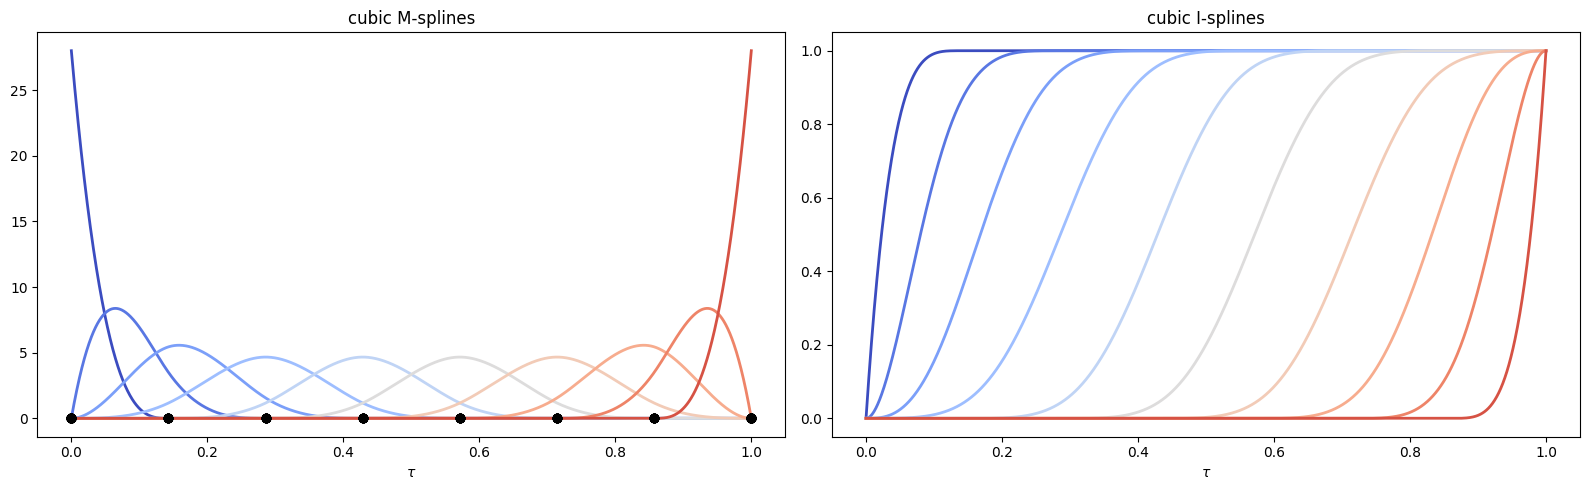

In [27]:
u = np.linspace(0, 1, 2000)
degree = 3
n_basis = 10

knots = make_open_nonuniform_knots(a = 0.0, b = 1.0, n_basis=n_basis, degree=degree, p = 3.0, kind="uniform")
M = mspline_basis(u, knots, degree=degree)             # (J, n_basis), nonnegative
I = ispline_basis_from_msplines(u, M)                  # (J, n_basis), monotone in u
I_uniform = I
# random positive weights (your NN would output these)
raw_a = rng.normal(size=n_basis)
a = softplus(raw_a) + 1e-6

b = -1.0  # location (can be learned / set)
Q = b + I @ a
qprime = M @ a  # derivative of Q wrt u (quantile density), nonnegative

# ---- plots ----
fig, ax = plt.subplots(1, 2, figsize=(16,5), sharex=False)

# I-spline basis
for i, m in enumerate(M.T):
    ax[0].plot(u, m, color = matplotlib.cm.coolwarm(i / M.shape[1]), lw = 2)
    ax[0].scatter(knots, np.zeros(len(knots)) , color = 'black', marker = 'o', zorder = 3)
for i, i_spline in enumerate(I.T):
    ax[1].plot(u, i_spline, color = matplotlib.cm.coolwarm(i / I.shape[1]), lw = 2)
    
ax[0].set_title("cubic M-splines")
ax[1].set_title("cubic I-splines")
ax[0].set_xlabel(r"$\tau$")
ax[1].set_xlabel(r"$\tau$")
plt.tight_layout()
plt.savefig('ispline_basis_uniform.png', dpi=300, transparent=True, bbox_inches='tight')

### Power tail knots (denser around edges)

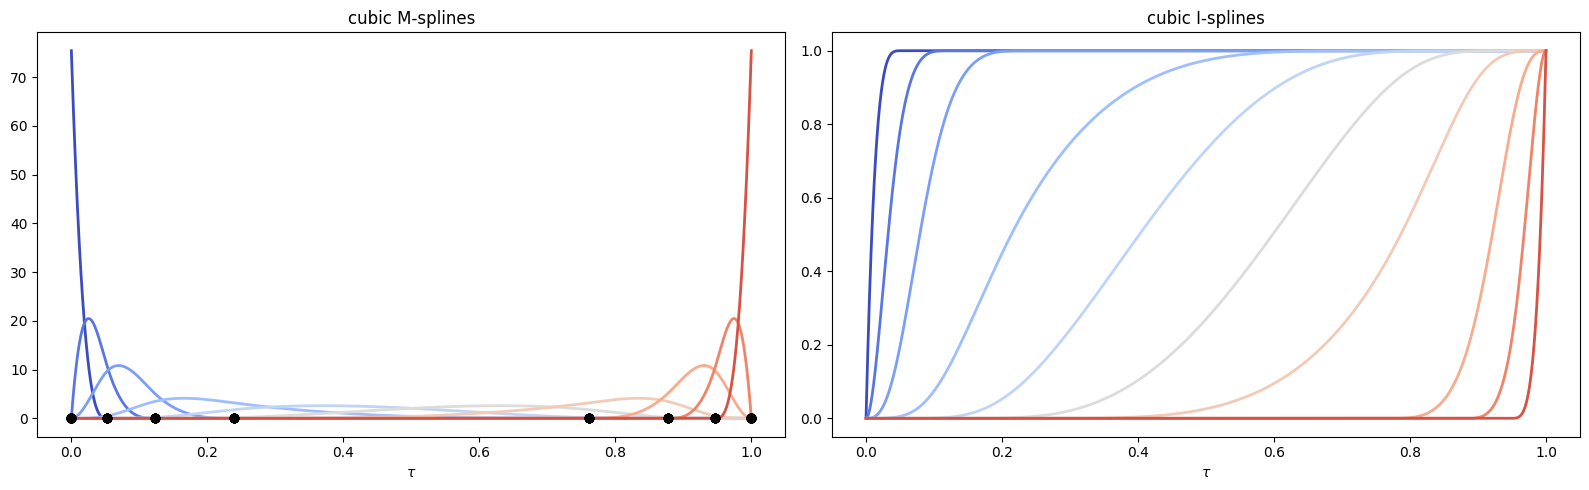

In [28]:
rng = np.random.default_rng(0)

u = np.linspace(0, 1, 2000)
degree = 3
n_basis = 10

knots = make_open_nonuniform_knots(a = 0.0, b = 1.0, n_basis=n_basis, degree=degree, p = 1/3, kind="power_tails")
M = mspline_basis(u, knots, degree=degree)             # (J, n_basis), nonnegative
I = ispline_basis_from_msplines(u, M)                  # (J, n_basis), monotone in u
I_power = I
# random positive weights (your NN would output these)
raw_a = rng.normal(size=n_basis)
a = softplus(raw_a) + 1e-6

b = -1.0  # location (can be learned / set)
Q = b + I @ a
qprime = M @ a  # derivative of Q wrt u (quantile density), nonnegative

# ---- plots ----
fig, ax = plt.subplots(1, 2, figsize=(16,5), sharex=False)

# I-spline basis
for i, m in enumerate(M.T):
    ax[0].plot(u, m, color = matplotlib.cm.coolwarm(i / M.shape[1]), lw = 2)
    ax[0].scatter(knots, np.zeros(len(knots)) , color = 'black', marker = 'o', zorder = 3)
for i, i_spline in enumerate(I.T):
    ax[1].plot(u, i_spline, color = matplotlib.cm.coolwarm(i / I.shape[1]), lw = 2)
    
ax[0].set_title("cubic M-splines")
ax[1].set_title("cubic I-splines")
ax[0].set_xlabel(r"$\tau$")
ax[1].set_xlabel(r"$\tau$")
plt.tight_layout()
plt.savefig('ispline_basis_power_tails.png', dpi=300, transparent=True, bbox_inches='tight')

/tmp/ipykernel_28942/1151966537.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mean_Q = np.trapz(Q_power, u)
/tmp/ipykernel_28942/1151966537.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  var_Q = np.trapz(Q_power**2, u) - mean_Q**2


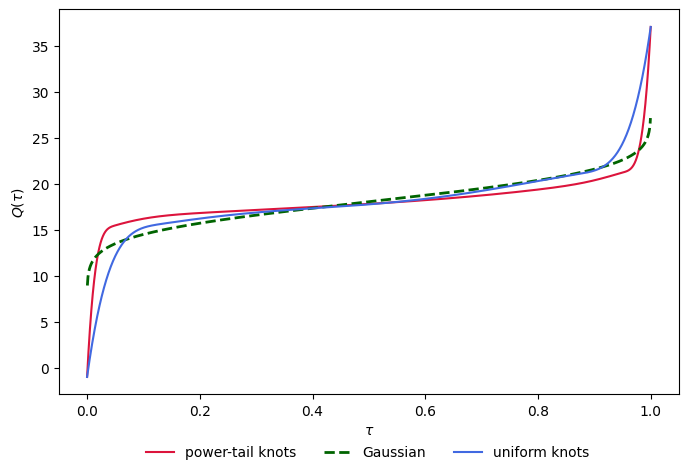

In [29]:
a = softplus(raw_a) + 1e-6
a[0] += 15.0  # make the first basis more dominant to show the effect 
a[-1] += 15.0  # make the first basis more dominant to show the effect 
b = -1.0  # location (can be learned / set)
Q_power = b + I_power @ a
Q_uniform = b + I_uniform @ a
qprime = M @ a  # derivative of Q wrt u (quantile density), nonnegative


mean_Q = np.trapz(Q_power, u)
# Variance = integral of Q(tau)^2 over [0,1] - mean^2
var_Q = np.trapz(Q_power**2, u) - mean_Q**2
std_Q = np.sqrt(var_Q)

plt.figure(figsize=(8,5))
# Gaussian quantile function with same location and scaleplt.savefig('quantile_function_comparison.png', dpi=300, transparent=True, bbox_inches='tight')

Q_gaussian = norm.ppf(u, loc=mean_Q, scale=std_Q)

plt.ylabel(r'$Q(\tau)$')

plt.xlabel(r'$\tau$')

plt.plot(u, Q_power, label = "power-tail knots", color = 'crimson', lw = 1.5)
plt.plot(u, Q_gaussian, label = "Gaussian", color = 'darkgreen', lw = 2, linestyle='--')
plt.plot(u, Q_uniform, label = "uniform knots", color = 'royalblue', lw = 1.5)
plt.legend(bbox_to_anchor=(0.12, -0.1), loc='upper left', ncols = 3, frameon = False)
plt.savefig('quantile_function_comparison.png', dpi=300, transparent=True, bbox_inches='tight')

- Power tail knots allow heavier tails (compare to gaussian with same mean/variance)

# Threshold weighted CRPS

- threshold weighted CRPS is used to train the model quantile function 
- Outcomes are weighed based on price (depeg) thresholds allowing for better calibration of the distribution for rar events
    - tail focus not based on quantile but on actual value exceedance 

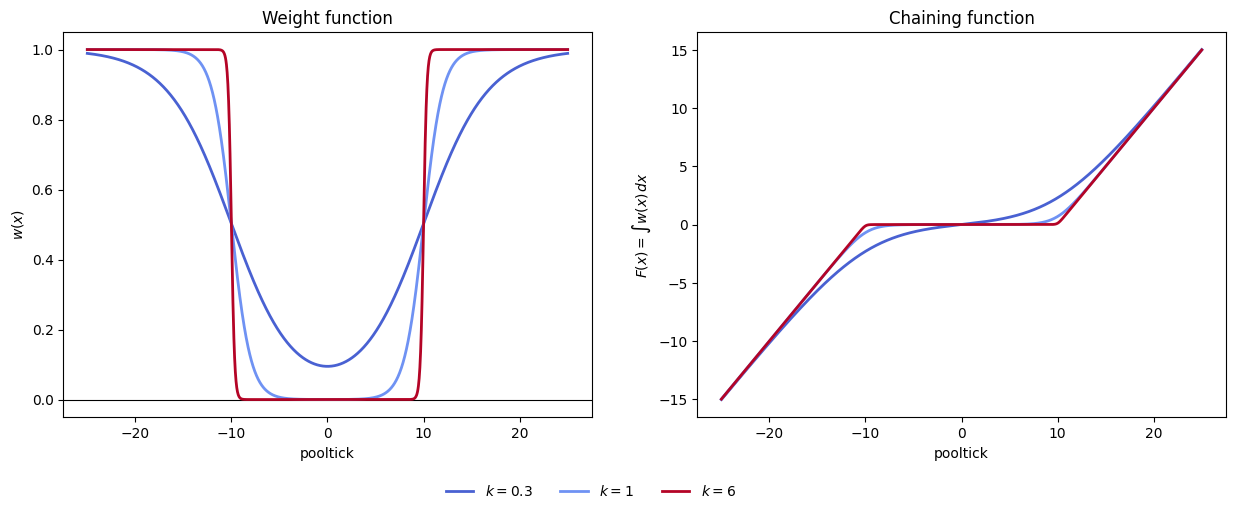

In [30]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def softplus(z):
    # numerically stable log(1+exp(z))
    return np.logaddexp(0.0, z)


def weight(x, k=0.1, delta=10):
    return sigmoid(-k*(x + delta))  + sigmoid(k*(x - delta))


def chaining(x, k=6.0, delta=0.7, C=0.0):
    return (softplus(k*(x - delta)) - softplus(-k*(x + delta))) / k + C


K = [0.3,1, 6]       # steepness
delta = 10   # half-width of the bump
x = np.linspace(-25, 25, 2000)


fig, ax = plt.subplots(1,2, sharex=False, figsize=(15, 5))

ax[0].axhline(0, color="k", lw=0.8)
ax[0].set_ylabel(r"$w(x)$")
ax[0].set_title("Weight function")

ax[0].set_xlabel("pooltick")
ax[1].set_xlabel("pooltick")
ax[1].set_ylabel(r"$F(x) = \int w(x) \, dx$")
ax[1].set_title("Chaining function")
for k in K :
    w = weight(x, k=k, delta=delta)
    F = chaining(x, k=k, delta=delta)
    ax[0].plot(x, w, lw=2, color=matplotlib.cm.coolwarm(k/max(K)))
    ax[1].plot(x, F, lw=2, color=matplotlib.cm.coolwarm(k/max(K)), label = r"$k={}$".format(k))
ax[1].legend(bbox_to_anchor=(-0.5, -0.14), loc='upper left', ncols = len(K), frameon = False)

plt.savefig('chaining_function.png', dpi=300, transparent=True, bbox_inches='tight')

## Spliced GPD Tails with I-Spline Body

The quantile function is modeled using a **hybrid approach**:
- **Main body** ($\tau \in [0.01, 0.99]$): I-spline regression with power-tail knots for smooth, flexible monotone interpolation
- **tails** ($\tau < 0.01$ and $\tau > 0.99$): Generalized Pareto Distribution (GPD) for heavy-tailed behavior

### Mathematical formulation

The full quantile function is defined as:
$$Q(\tau) = \begin{cases}
Q_{\text{lower}}(\tau) & \text{if } \tau < \tau_{\text{low}} = 0.01 \\
Q_{\text{body}}(\tau) & \text{if } \tau_{\text{low}} \leq \tau \leq \tau_{\text{high}} = 0.99 \\
Q_{\text{upper}}(\tau) & \text{if } \tau > \tau_{\text{high}}
\end{cases}$$

where:
- $Q_{\text{body}}(\tau) = b + \sum_k w_k I_k(\tau)$ is the I-spline regression on the main body
- $Q_{\text{lower}}(\tau) = Q(\tau_{\text{low}}) + \sigma_L \cdot G^{-1}(\frac{\tau}{\tau_{\text{low}}}, \xi_L)$ is the lower tail GPD 
- $Q_{\text{upper}}(\tau) = Q(\tau_{\text{high}}) + \sigma_U \cdot G^{-1}(\frac{\tau - \tau_{\text{high}}}{1 - \tau_{\text{high}}}, \xi_U)$ is the upper tail GPD

The GPD is parameterized by shape ($\xi$) and scale ($\sigma$), capturing asymptotic tail behavior. Splicing ensures **smooth continuity** at the splice points $\tau_{\text{low}}$ and $\tau_{\text{high}}$ while allowing the tails to exhibit power-law decay typical of financial returns and extreme events.

In [47]:
u_low, u_high = 0.05, 0.995
xiL, xiU = 0.01, 0.02      # positive xi = Pareto/heavy tail
eps = 1e-10

Q_mono = np.maximum.accumulate(Q)

xL = np.interp(u_low, u, Q_mono)
xU = np.interp(u_high, u, Q_mono)
qL = max(np.interp(u_low, u, qprime), eps)
qU = max(np.interp(u_high, u, qprime), eps)

# slope matching
betaL = u_low * qL
betaU = (1.0 - u_high) * qU

def gpd_survival(d, beta, xi):
    d = np.asarray(d)
    if abs(xi) < 1e-8:
        return np.exp(-d / beta)
    base = 1.0 + xi * d / beta
    return np.where(base > 0, base ** (-1.0 / xi), 0.0)

def Q_lower(uu):
    r = np.clip(uu / u_low, eps, 1.0)
    if abs(xiL) < 1e-8:
        return xL + betaL * np.log(r)
    return xL - (betaL / xiL) * (r ** (-xiL) - 1.0)

def Q_upper(uu):
    r = np.clip((1.0 - uu) / (1.0 - u_high), eps, 1.0)
    if abs(xiU) < 1e-8:
        return xU - betaU * np.log(r)
    return xU + (betaU / xiU) * (r ** (-xiU) - 1.0)

def Q_spliced(uu):
    uu = np.asarray(uu)
    out = np.empty_like(uu, dtype=float)
    lo = uu < u_low
    mid = (uu >= u_low) & (uu <= u_high)
    hi = uu > u_high
    out[lo] = Q_lower(uu[lo])
    out[mid] = np.interp(uu[mid], u, Q_mono)
    out[hi] = Q_upper(uu[hi])
    return out

def F_spliced(z):
    z = np.asarray(z)
    F = np.empty_like(z, dtype=float)

    lo = z < xL
    mid = (z >= xL) & (z <= xU)
    hi = z > xU

    F[lo] = u_low * gpd_survival(xL - z[lo], betaL, xiL)
    F[mid] = np.interp(z[mid], Q_mono, u)
    F[hi] = 1.0 - (1.0 - u_high) * gpd_survival(z[hi] - xU, betaU, xiU)

    return np.clip(F, 0.0, 1.0)

print(f"lower splice: u={u_low}, xL={xL:.3f}, betaL={betaL:.3g}, xiL={xiL}")
print(f"upper splice: u={u_high}, xU={xU:.3f}, betaU={betaU:.3g}, xiU={xiU}")

lower splice: u=0.05, xL=0.462, betaL=0.895, xiL=0.01
upper splice: u=0.995, xU=6.928, betaU=4.29, xiU=0.02


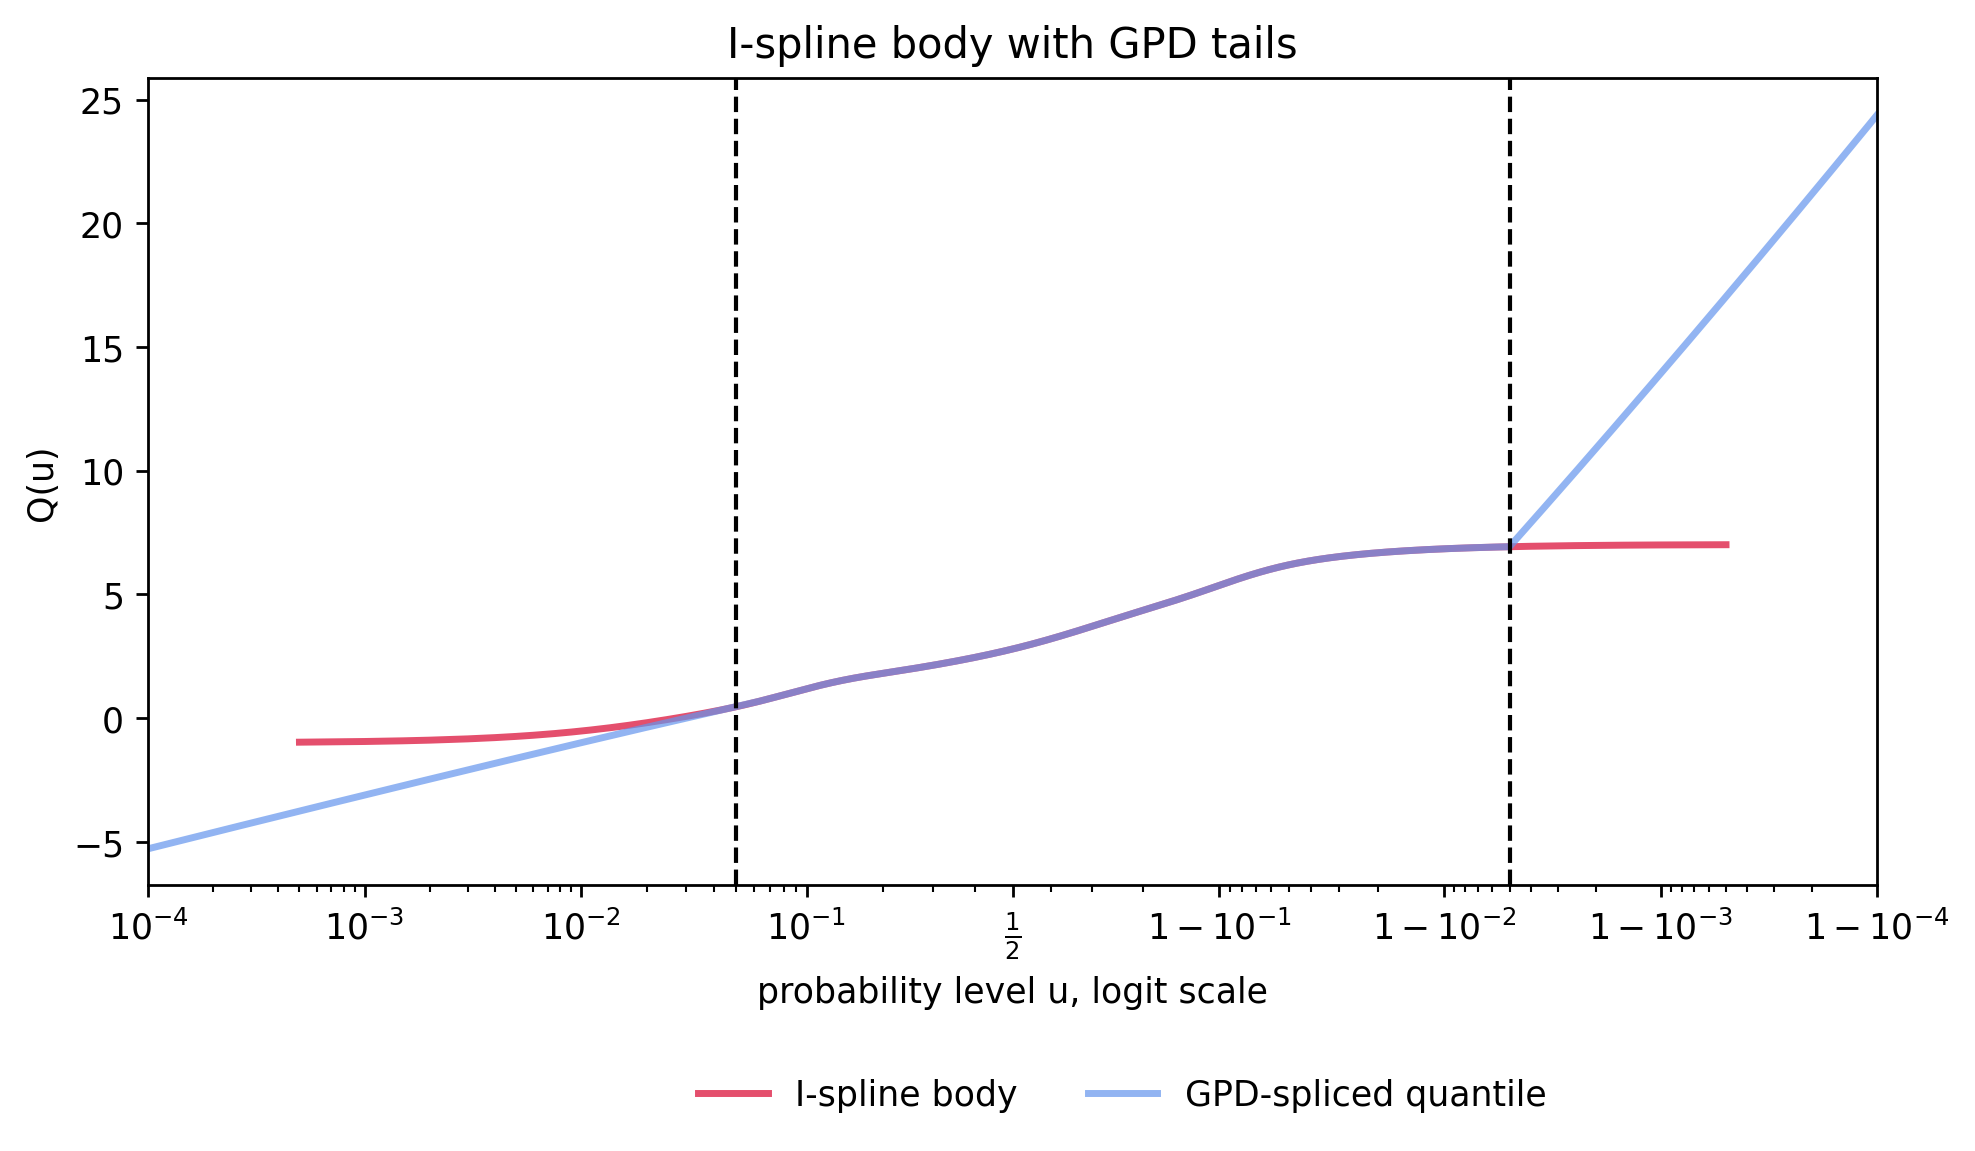

In [56]:
u_plot = np.r_[np.geomspace(1e-4, u_low, 400),
               np.linspace(u_low, u_high, 1200),
               1.0 - np.geomspace(1e-4, 1-u_high, 400)[::-1]]

Q_plot = Q_spliced(u_plot)

fig, ax = plt.subplots(figsize=(8, 4.8), dpi=250)

ax.plot(u, Q_mono, color="crimson", lw=2, alpha=0.75, label="I-spline body")
ax.plot(u_plot, Q_plot, color="cornflowerblue", lw=2, alpha = 0.7, label="GPD-spliced quantile")

# ax.scatter([u_low, u_high], [xL, xU], color="crimson", zorder=5, label="splice points")
ax.axvline(u_low, color="black", ls="--", lw=1.2)
ax.axvline(u_high, color="black", ls="--", lw=1.2)

ax.set_xscale("logit")
ax.set_xlim(1e-4, 1 - 1e-4)   # clipped so body remains visible

ax.set_xlabel("probability level u, logit scale")
ax.set_ylabel("Q(u)")
ax.set_title("I-spline body with GPD tails")
ax.legend(bbox_to_anchor=(.3, -0.2), ncols = 2, loc='upper left', frameon=False)
# ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("gpd_spliced_quantile_logit.png", dpi=300, transparent=True, bbox_inches="tight")
plt.show()

### Closed-form ES from the spliced GPD tails

Beyond the splice points, the model assumes GPD/Pareto-type tails.

For the upper tail, if  
$$
1 - F(z) = (1-u_U) S_{\mathrm{GPD}}(z-x_U),
$$
then for a tail probability \(\alpha < 1-u_U\),

$$
\mathrm{VaR}^{upper}_\alpha = x_U + d_\alpha,
$$

where \(d_\alpha\) solves

$$
S_{\mathrm{GPD}}(d_\alpha) = \frac{\alpha}{1-u_U}.
$$

For a GPD tail with scale \(\beta\) and shape \(\xi < 1\),

$$
\mathbb{E}[D \mid D \ge d_\alpha]
=
\frac{d_\alpha + \beta}{1-\xi}.
$$

Therefore,

$$
\mathrm{ES}^{upper}_\alpha
=
x_U + \frac{d_\alpha + \beta_U}{1-\xi_U}.
$$

Similarly, for the lower tail,

$$
\mathrm{ES}^{lower}_\alpha
=
x_L - \frac{d_\alpha + \beta_L}{1-\xi_L}.
$$

So the GPD splice gives closed-form VaR/ES estimates for probabilities rarer than the body grid, e.g. \(10^{-3}\), \(10^{-4}\), etc.